# Annoation and Segmentation

## Sampling 100 images with seed = 42

In [1]:
import os
import shutil
import pandas as pd

from pathlib import Path

### Setup path

In [2]:
images_dir     = Path("../data/Radiographs/")
csv_path       = Path("../data/image_age.csv")
annotation_dir = Path("../data/Annotation-batch-01/")

In [3]:
df = pd.read_csv(csv_path)
df.head()

,file_name,age
0,0856-001-01.jpg,23
1,1375-001-02.jpg,28
2,0181-001-01.jpg,33
3,1358-002-01.jpg,44
4,2367-001-01.jpg,55


In [4]:
sample = df.sample(n=100, random_state=42)

### Copy sampled files to annotation-batch-01

In [5]:
count = 0
for _, row in sample.iterrows():
    img_name = row['file_name']
    src_path = images_dir / img_name
    dest_path = annotation_dir / img_name
    
    if src_path.exists():
        shutil.copy2(src_path, dest_path)
        count += 1

sample.to_csv("../data/annotation_batch_01.csv", index=False)

print(f"Successfully copied {count} images to {annotation_dir}")

Successfully copied 100 images to ../data/Annotation-batch-01


# :)

In [6]:
import cv2

img = cv2.imread('../data/Radiographs/0651-001-02.jpg', 0)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced_img = clahe.apply(img)

cv2.imwrite('./enhanced_forensic_image.png', enhanced_img)

True

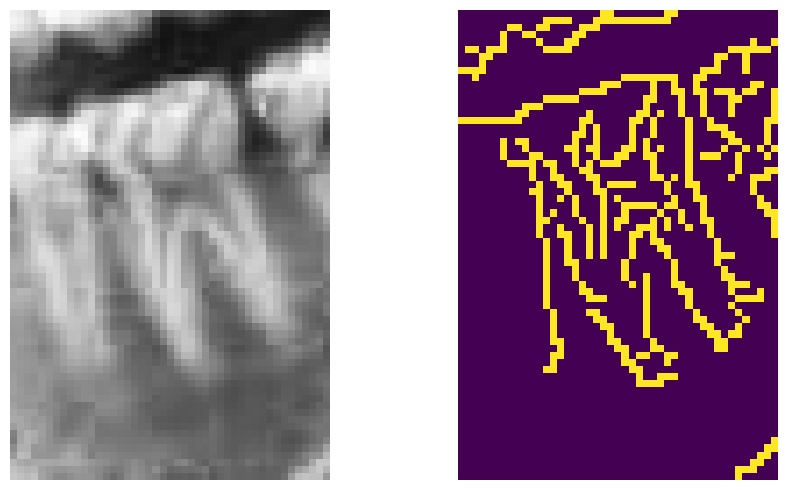

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("cropped_tooth.png")

edges = cv2.Canny(img, 110, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].axis('off')
axes[1].imshow(edges)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Enhance Batch 01 Images

In [9]:
enhanced_dir = Path("../data/Annotation-batch-01-enhanced/")
enhanced_dir.mkdir(parents=True, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

enhanced_count = 0
for img_path in annotation_dir.iterdir():
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            enhanced = clahe.apply(img)
            cv2.imwrite(str(enhanced_dir / img_path.name), enhanced)
            enhanced_count += 1

print(f"Successfully enhanced {enhanced_count} images in {enhanced_dir}")

Successfully enhanced 100 images in ../data/Annotation-batch-01-enhanced


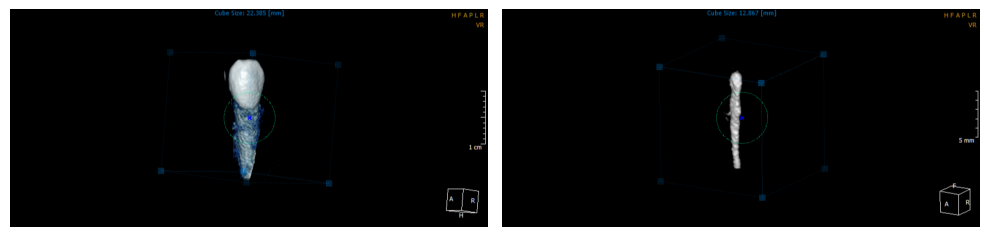

In [14]:
devika_tooth = cv2.imread("../data_temp/kari/21-30/females/devika@23/Xelis_Dental_Report000.bmp")
devika_pulp  = cv2.imread("../data_temp/kari/21-30/females/devika@23/Xelis_Dental_Report001.bmp")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(devika_tooth)
axes[0].axis('off')
axes[1].imshow(devika_pulp)
axes[1].axis('off')

plt.tight_layout()
plt.show()